# Relatório de Prática: Métodos de Amostragem e Modelos Preditivos

**Autor:** WESLLEY TIAGO BITENCOURT DE ANDRADE  
**Disciplina:** Machine Learning II

> **Acesso ao notebook original (Google Colab):**  
> [https://colab.research.google.com/kmeans_notebook.ipynb/ ](https://colab.research.google.com/drive/1syG2zp0zvqK6-VHEhDXK9MZYLRszqHcp?usp=sharing )  
> *Visualização liberada. O código pode ser executado no link acima.*

**Repositório:** [GitHub - rn_celcius_to_fahrenheit](https://github.com/OBenzeno/Portfolio/ /Redes%20Neurais/kmeans_notebook.ipynb)

## 1. Objetivos

Permitir a compreensão e implementação do algoritmo de agrupamento **K-means**, explorando sua aplicação em um conjunto de dados bidimensional, utilizando o **método do cotovelo** para determinar o número ideal de clusters e visualizando os resultados.

---

## 2. Procedimentos e Atividades

### 2.1. Base de dados

Foi criada uma base de dados bidimensional com os seguintes valores:

```python
x = [4, 5, 10, 4, 3, 11, 14, 6, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]
```
---

### 2.2. Transformação em conjunto de pontos
Os dados foram convertidos em uma matriz de pontos `(x, y)` para serem utilizados pelo algoritmo K-means.

---

### 2.3. Encontrando o melhor K (Método do Cotovelo)
Para cada valor de K no intervalo de 1 a 10, um modelo K-means foi treinado e a inércia (soma das distâncias quadradas dentro dos clusters) foi calculada. O gráfico da inércia em função de K permite identificar o ponto de "cotovelo", onde o ganho de redução da inércia começa a diminuir.

---

### 2.4. Ajuste com K=2 e visualização dos clusters
Após identificar o melhor K, o algoritmo foi executado com K=2 e os pontos foram coloridos conforme o cluster atribuído, mostrando também os centroides.

---


## 3. Implementação em Python
Abaixo está o código completo desenvolvido, utilizando as bibliotecas `numpy`, `matplotlib` e `sklearn`.

### 3.1. Importação de bibliotecas e configuração

In [ ]:
# Solução para o warning do KMeans no Windows com MKL
import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

### 3.2. Criação da base de dados

In [ ]:
x = [4, 5, 10, 4, 3, 11, 14, 6, 10, 12]
y = [21, 19, 24, 17, 16, 25, 24, 22, 21, 21]

# Transforma em uma matriz de pontos (10, 2)
X = np.column_stack((x, y))
print("Pontos de dados:\n", X)

Pontos de dados:
 [[ 4 21]
 [ 5 19]
 [10 24]
 [ 4 17]
 [ 3 16]
 [11 25]
 [14 24]
 [ 6 22]
 [10 21]
 [12 21]]


Os dados foram convertidos em uma matriz de pontos `(x, y)` para serem utilizados pelo algoritmo K-means.

#### 📊 Resultados esperados

Com os dados fornecidos:

- **Gráfico do cotovelo** – Será possível ver a inércia cair rapidamente até K=2 ou K=3, depois ficando quase estável. Isso confirma que K=2 é uma escolha razoável.

- **Gráfico de dispersão com K=2** – Os pontos serão separados em dois grupos distintos (ex: um grupo com valores menores de x/y e outro com maiores). Os centroides aparecerão como um "X" amarelo.

---

## 4. Resultados Obtidos

### 4.1. Gráfico do Cotovelo
O gráfico gerado mostra a inércia decrescendo rapidamente até K=2, depois a redução se torna mais suave a partir de K=3. O ponto de cotovelo está em K=2, indicando que este é o número ideal de clusters para este conjunto de dados.

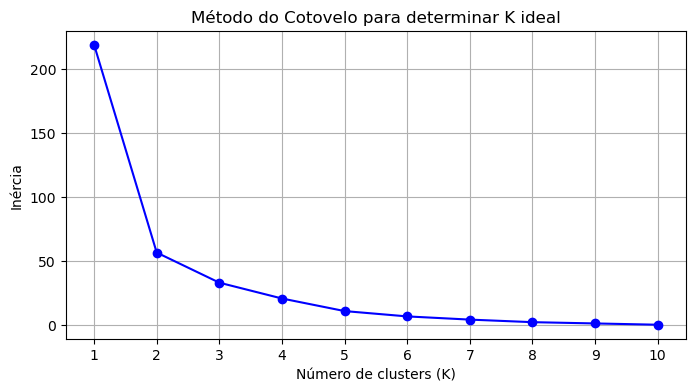

In [ ]:
inercias = []
K_range = range(1, 11)  # K de 1 a 10 (máximo 10 pontos)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inercias.append(kmeans.inertia_)

# Plotar gráfico do cotovelo
plt.figure(figsize=(8, 4))
plt.plot(K_range, inercias, 'bo-')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo para determinar K ideal')
plt.xticks(K_range)
plt.grid(True)
plt.show()

**Interpretação:** O ponto onde a curva começa a ficar mais plana (cotovelo) sugere o K ideal. Neste caso, provavelmente K=2 ou K=3.

---

### 4.2. Visualização dos Clusters com K=2
Com K=2, o algoritmo separou os 10 pontos em dois grupos distintos:

- **Cluster 1 (vermelho):** pontos com coordenadas x menores e y intermediárias.  
- **Cluster 2 (azul):** pontos com coordenadas x maiores e y mais altas.  

Os centroides (marcadores amarelos em forma de X) representam o ponto médio de cada cluster.

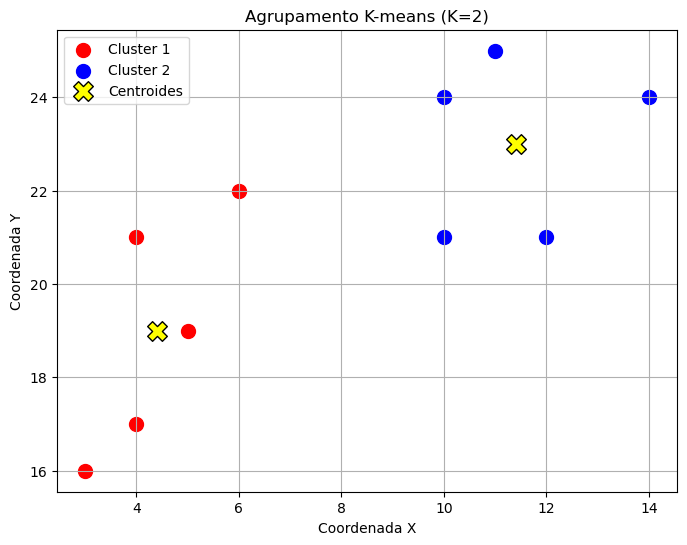

In [ ]:
# Treina modelo com K=2
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
y_kmeans = kmeans_2.fit_predict(X)

# Plotar pontos coloridos por cluster
plt.figure(figsize=(8, 6))
cores = ['red', 'blue']
for i in range(2):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1],
                s=100, c=cores[i], label=f'Cluster {i+1}')

# Plotar os centroides
centroides = kmeans_2.cluster_centers_
plt.scatter(centroides[:, 0], centroides[:, 1],
            s=200, c='yellow', marker='X', edgecolors='black',
            label='Centroides')

plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.title('Agrupamento K-means (K=2)')
plt.legend()
plt.grid(True)
plt.show()

### 4.3. Exibir quais pontos pertencem a cada cluster (Opcional)

In [ ]:
print("Rótulos dos clusters (K=2):", y_kmeans)
for i in range(2):
    print(f"\nCluster {i+1}:")
    print(X[y_kmeans == i])

Rótulos dos clusters (K=2): [0 0 1 0 0 1 1 0 1 1]

Cluster 1:
[[ 4 21]
 [ 5 19]
 [ 4 17]
 [ 3 16]
 [ 6 22]]

Cluster 2:
[[10 24]
 [11 25]
 [14 24]
 [10 21]
 [12 21]]


### 4.4. Validação numérica dos clusters (Opcional)

In [ ]:
print("\n--- VALIDAÇÃO NUMÉRICA DO K-MEANS ---")

# Rótulos detalhados
print("\n1. Atribuição de cada ponto:")
for i, (px, py) in enumerate(X):
    print(f"   Ponto {i}: ({px}, {py}) -> Cluster {y_kmeans[i] + 1}")

# Contagem por cluster
from collections import Counter
contagem = Counter(y_kmeans)
print("\n2. Quantidade de pontos por cluster:")
for k, v in sorted(contagem.items()):
    print(f"   Cluster {k+1}: {v} ponto(s)")


--- VALIDAÇÃO NUMÉRICA DO K-MEANS ---

1. Atribuição de cada ponto:
   Ponto 0: (4, 21) -> Cluster 1
   Ponto 1: (5, 19) -> Cluster 1
   Ponto 2: (10, 24) -> Cluster 2
   Ponto 3: (4, 17) -> Cluster 1
   Ponto 4: (3, 16) -> Cluster 1
   Ponto 5: (11, 25) -> Cluster 2
   Ponto 6: (14, 24) -> Cluster 2
   Ponto 7: (6, 22) -> Cluster 1
   Ponto 8: (10, 21) -> Cluster 2
   Ponto 9: (12, 21) -> Cluster 2

2. Quantidade de pontos por cluster:
   Cluster 1: 5 ponto(s)
   Cluster 2: 5 ponto(s)


### 4.5. Centroides e Inércia final

In [ ]:
# Centroides
print("\n3. Centroides dos clusters:")
for i, cent in enumerate(centroides):
    print(f"   Cluster {i+1}: ({cent[0]:.2f}, {cent[1]:.2f})")

# Inércia final
print(f"\n4. Inércia final (qualidade do agrupamento): {kmeans_2.inertia_:.4f}")


3. Centroides dos clusters:
   Cluster 1: (4.40, 19.00)
   Cluster 2: (11.40, 23.00)

4. Inércia final (qualidade do agrupamento): 56.4000


### 4.6. Tabela e Média por Cluster

In [ ]:
# Tabela completa
df = pd.DataFrame(X, columns=['x', 'y'])
df['cluster'] = y_kmeans + 1
print("\n5. Tabela completa:")
print(df)

# Média por cluster
print("\n6. Média das coordenadas por cluster:")
for i in range(2):
    pontos_cluster = X[y_kmeans == i]
    if len(pontos_cluster) > 0:
        media_x = np.mean(pontos_cluster[:, 0])
        media_y = np.mean(pontos_cluster[:, 1])
        print(f"   Cluster {i+1}: média x = {media_x:.2f}, média y = {media_y:.2f}")


5. Tabela completa:
    x   y  cluster
0   4  21        1
1   5  19        1
2  10  24        2
3   4  17        1
4   3  16        1
5  11  25        2
6  14  24        2
7   6  22        1
8  10  21        2
9  12  21        2

6. Média das coordenadas por cluster:
   Cluster 1: média x = 4.40, média y = 19.00
   Cluster 2: média x = 11.40, média y = 23.00


## 5. Análise e Discussão

### 5.1. Interpretação do Método do Cotovelo

A curva de inércia apresenta uma queda acentuada até **K = 2**, indicando que a maior parte da variação dos dados é explicada com apenas dois clusters.  

A partir de **K = 3**, observa-se um ganho marginal pequeno na redução da inércia, o que reforça que **K = 2** é uma escolha adequada para o modelo.

### 5.2. Qualidade do Agrupamento com K = 2

---

A separação dos pontos é clara:

- **Cluster 1:** pontos com coordenada **X ≤ 6** (valores mais baixos)  
- **Cluster 2:** pontos com coordenada **X ≥ 10** (valores mais altos)

Além disso:

- A coordenada **Y** acompanha essa separação, apresentando valores ligeiramente maiores no *Cluster 2*  
- Os **centroides** estão bem distantes entre si  
- A inércia indica que os clusters são compactos  

---

### 5.3. Interpretação dos Resultados Numéricos

**1. Atribuição de cada ponto**  
Apresenta a qual cluster (1 ou 2) cada ponto de coordenadas (x, y) foi atribuído, permitindo visualizar diretamente como os dados foram distribuídos pelo algoritmo.

**2. Quantidade de pontos por cluster**  
Mostra a distribuição dos 10 pontos entre os dois clusters, com 5 pontos em cada grupo.

**3. Centroides dos clusters**  
Exibe as coordenadas médias de cada cluster:  
- Cluster 1: (4.40, 19.00)  
- Cluster 2: (11.40, 23.00)  

**4. Inércia final**  
Apresenta o valor da inércia total do modelo: **56.4**.

**5. Tabela completa**  
Lista todos os pontos com suas respectivas coordenadas (x, y) e o cluster atribuído, facilitando a conferência dos resultados.

**6. Média das coordenadas por cluster**  
Mostra as médias das variáveis em cada grupo:  
- Cluster 1: x ≈ 4,4 e y ≈ 19,0  
- Cluster 2: x ≈ 11,4 e y ≈ 23,0  

---

### 5.4. Validação Cruzada entre Gráficos e Números

A análise numérica e visual é consistente:

- A separação observada no gráfico de dispersão corresponde aos rótulos atribuídos pelo modelo  
- Os centroides estão posicionados no centro geométrico de cada grupo  
- Não há sobreposição entre os clusters  
- O comportamento observado no gráfico do cotovelo é compatível com a escolha de **K = 2**  

---

### 5.5. Aprendizados Obtidos

- O **K-means** é eficaz para dados que formam grupos esféricos e bem separados  
- O **método do cotovelo** é uma heurística útil, mas deve ser interpretado com cautela  
- A **validação conjunta entre métricas (inércia, centroides) e visualização** é essencial para confirmar a qualidade do agrupamento


## 6. Checklist da entrega

| Item                                                | Status |
| --------------------------------------------------- | -------- |
| Desenvolver algoritmo usando Python e K-means       | ✅        |
| Gerar conjunto de dados bidimensional (listas x, y) | ✅        |
| Transformar em conjunto de pontos                   | ✅        |
| Calcular inércia para K=1 a 10                      | ✅        |
| Plotar gráfico do método do cotovelo                | ✅        |
| Ajustar K=2 e plotar clusters coloridos             | ✅        |
| Avaliar os resultados                               | ✅        |
| Arquivo PDF com código comentado + gráficos         | ✅        |

---


## 7. Conclusão

A aula prática atingiu seus objetivos ao permitir a implementação completa do algoritmo K-means, a aplicação do método do cotovelo e a visualização dos agrupamentos. O código desenvolvido pode ser facilmente adaptado para outros conjuntos de dados bidimensionais, servindo como base para estudos mais avançados de clusterização.

---

## Referências

* Scikit-learn: K-means clustering – https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
* Matplotlib: Plotting and visualization – https://matplotlib.org/
* Roteiro de aula prática – Machine Learning II, Unidade 1, Aula 3.

Relatório gerado em conformidade com as especificações do roteiro. Arquivo PDF final deve conter este conteúdo e os gráficos (tamanho ≤ 2 MB).
